In [17]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom

#jax.config.update('jax_platform_name', 'cpu')

# Set default device to CPU


from functools import partial

import haiku as hk

import matplotlib.pyplot as plt

from probjax.core import rv

import optax

from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss
from probjax.distributions.sde import VESDE, VPSDE
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Independent, Empirical, Uniform
from probjax.utils.odeint import _odeint

In [18]:
prior = Normal(jnp.zeros((1,)), jnp.ones((1,))) 

In [149]:

# # VESDE 
# T = 1.
# T_min = 1e-5
# sigma_min = 0.01
# sigma_max = 10.

# thetas = prior.sample(jax.random.PRNGKey(0), (10000,))
# p0 = Independent(Empirical(thetas), 1) # Empirical distribution of the data
# sde = VESDE(p0, sigma_min=sigma_min , sigma_max=sigma_max)

# def output_scale_fn(t, x):
#     scale = sde.marginal_stddev(t, jnp.ones_like(x))
#     return (1/scale * x).reshape(x.shape)

# def weight_fn(t):
#     return jnp.clip(sde.diffusion(t, jnp.ones((1,1,1)))**2, 1e-4)

In [203]:

# VPSDE 
T = 1.
T_min = 1e-5
beta_min = 0.01
beta_max = 20.

thetas = prior.sample(jax.random.PRNGKey(0), (10000,))
p0 = Independent(Empirical(thetas), 1) # Empirical distribution of the data
sde = VPSDE(p0, beta_min=beta_min , beta_max=beta_max)

def output_scale_fn(t, x):
    scale = sde.marginal_stddev(t, jnp.ones_like(x))
    return (1/scale * x).reshape(x.shape)

def weight_fn(t):
    return 1-jnp.exp(-0.5 * (beta_max - beta_min) * t**2 - beta_min * t) + 1e-5

In [204]:
# s(theta| x_t, x_t+1)
# x_t R^2, x_t+1 R^2
hidden_dim = 50
activation = jax.nn.gelu
num_hidden = 4
layer_norm = True

def score_net(a, theta, x_t0, x_t1):
    
    context = jnp.concatenate([x_t0, x_t1], axis=-1) 

    time_embedding = GaussianFourierEmbedding(hidden_dim)(a[..., None])
    
    h1 = hk.Linear(hidden_dim//2)(context)
    h2 = hk.Linear(hidden_dim - hidden_dim//2)(theta)
    
    h = activation(jnp.concatenate([h1, h2], axis=-1) + time_embedding)

    for _ in range(num_hidden - 1):
        h_new = hk.Linear(hidden_dim)(h)
        h_new += time_embedding
        h = activation(h_new)

        if layer_norm:
            h = hk.LayerNorm(axis=-1, create_scale=True, create_offset=True)(h)

    out = hk.Linear(theta.shape[-1])(h)
    return out.reshape(theta.shape)


In [205]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones((10,)), thetas[:10], jnp.ones((10, 1)), jnp.ones((10, 1))) # Initialize the parameters of the model

In [206]:
sigma_x0 = 10.
def generate_data(key, n):
    key1, key2, key3 = jax.random.split(key, 3)
    
    theta_batch = jax.random.normal(key1, (n,1))
    x_t = jax.random.normal(key2, (n,1))*sigma_x0    
    x_t1 =  x_t + theta_batch + jax.random.normal(key3, (n,1)) 
    return theta_batch, x_t, x_t1


In [230]:
theta_batch, x_t0, x_t1 = generate_data(jax.random.PRNGKey(0), 10)

In [231]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones(10),theta_batch, x_t0, x_t1) # Initialize the parameters of the model

In [232]:


def loss_fn(params, key, batch_size= 1024):

    rng_time, rng_data, rng_sample = jax.random.split(key, 3)
    
    # Generate data and random times
    times = jax.random.uniform(rng_time, (batch_size,), minval=T_min, maxval=1.0)
    theta_batch, x_t0, x_t1 = generate_data(rng_data, batch_size) # n, T_max, 1
    

    # Forward diffusion, do not perturb conditioned data
    loss = denoising_score_matching_loss(params, rng_sample, times, theta_batch, None, model_fn= model_fn, mean_fn=sde.marginal_mean, std_fn = sde.marginal_stddev, weight_fn=weight_fn, x_t0=x_t0, x_t1=x_t1, axis=-1)
    
    return loss


In [237]:
@partial(jax.pmap, axis_name="num_devices")
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    
    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [238]:

optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.adam(5e-4))
opt_state = optimizer.init(params)

In [239]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [240]:
key = jrandom.PRNGKey(0)

In [241]:
for _ in range(10):
    l = 0
    for i in range(500):
        key, subkey = jrandom.split(key)
        loss, replicated_params, replicated_opt_state = update(replicated_params, jax.random.split(subkey, (n_devices,)), replicated_opt_state)
        l += loss[0] / 500
    print(l)

0.31396106
0.23673628
0.23217596
0.2345216
0.23245367
0.2327254
0.23175995
0.2313243
0.23382388
0.23095204


In [242]:
for _ in range(10):
    l = 0
    for i in range(500):
        key, subkey = jrandom.split(key)
        loss, replicated_params, replicated_opt_state = update(replicated_params, jax.random.split(subkey, (n_devices,)), replicated_opt_state)
        l += loss[0] / 500
    print(l)

0.23527445
0.23263997
0.23127438
0.23416856
0.23197566
0.23280552
0.23251809
0.23199968
0.2309576
0.23316282


In [243]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [244]:
t = jnp.linspace(-3,3, 1000)
t = t.reshape(-1, 1)    
s = model_fn(params, jnp.array([T_min]*1000), t, jnp.zeros((1000,1)),  jnp.ones((1000,1)))

In [245]:
@jax.grad
def true_score(theta, x_t0, x_t1):
    return jax.scipy.stats.norm.logpdf(theta, 0.5*(x_t1 - x_t0), jnp.sqrt(0.5)).sum()

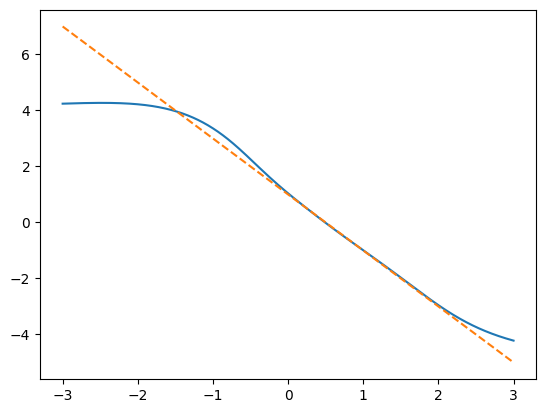

In [246]:
plt.plot(t, s)
plt.plot(t, jax.vmap(true_score, in_axes=(0,None,None))(t, 0.,1.0), "--")

In [247]:
theta_o = jnp.array([-0.5])

x_0 = jnp.array([0.])
xs = [x_0]
for i in range(50):
    x_1 = x_0 + theta_o + jax.random.normal(jrandom.PRNGKey(i+2), (1,))
    x_0 = x_1
    xs.append(x_1)
    
x_o = jnp.array(xs)[:,0]

In [248]:
theta = theta_o
t = jnp.array([0.1])

In [249]:
x_past = x_o[:-1, None]
x_future = x_o[1:,None]

In [250]:
jax.devices()

[CpuDevice(id=0)]

In [251]:
from functools import partial
from probjax.utils.sdeint import sdeint


# Reverse SDE drift
def drift_backward(t, theta, x_o):
    #x1, x2 = jnp.split(x_o, 2)
    
    x_past = x_o[:-1, None]
    x_future = x_o[1:,None]
    
    theta_batch = jnp.broadcast_to(theta, (x_past.shape[0], theta.shape[-1]))
    increment_scores = model_fn(params, t, theta_batch, x_past, x_future)
    N = increment_scores.shape[0]
    prior_score = (1-t)*jax.grad(lambda x: prior.log_prob(x).sum())(theta) 
   
    score = increment_scores.sum(axis=0) - (N-1)*prior_score

    score = score.reshape(theta.shape)

    f =  sde.drift(t,theta) - sde.diffusion(t,theta)**2 * score
    
    return f

# Reverse SDE diffusion
def diffusion_backward(t,theta):
    #t = T - t
    b =  sde.diffusion(t,theta) 
    return b

In [252]:

end_std = jnp.squeeze(sde.marginal_stddev(jnp.ones(1)))
end_mean = jnp.squeeze(sde.marginal_mean(jnp.ones(1)))

def sample_fn(key, shape,x_o, time_steps=500):
    key1, key2 = jrandom.split(key, 2)
    # Sample from noise distribution at time 1
    x_T = jax.random.normal(key1, shape + (1,)) * end_std + end_mean
    
    # Sove backward sde
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, x_o=x_o), lambda t, x: diffusion_backward(t, x), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys


In [253]:
x_o

Array([  0.   ,  -0.692,  -0.087,  -1.572,  -1.729,  -2.189,  -1.677,
        -0.825,  -0.92 ,  -2.765,  -3.384,  -4.398,  -3.988,  -5.255,
        -5.685,  -6.055,  -6.999,  -5.963,  -5.805,  -7.049,  -7.43 ,
        -6.485,  -6.727,  -8.396,  -9.219, -10.025, -12.464, -13.229,
       -13.694, -12.763, -12.464, -12.284, -11.959, -11.799, -12.724,
       -13.813, -14.999, -12.856, -13.359, -13.717, -14.004, -14.689,
       -14.379, -17.228, -16.744, -16.593, -16.711, -17.135, -16.586,
       -16.504, -18.429], dtype=float32)

In [254]:
def true_posterior(x_o):
    
    x_past = x_o[:-1, None]
    x_future = x_o[1:,None]
    
    mean_posterior = (x_future- x_past)/2
    std_posterior = 1/jnp.sqrt(2)
    return Normal(mean_posterior, std_posterior)

In [255]:
samples = sample_fn(jrandom.PRNGKey(0), (1000,), x_o)

In [256]:
# l = jnp.linspace(-5, 5, 100)
# Z = jnp.exp(true_posterior(x_o).log_prob(l[:,None]).sum(-1))

(array([0.145, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.145, 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.145, 0.289, 0.   , 0.   , 0.145,
        0.145, 0.579, 0.289, 0.   , 0.723, 0.145, 0.   , 0.289, 0.579,
        0.   , 0.289, 2.17 , 1.012, 1.012, 1.012, 2.459, 1.157, 1.736,
        1.736, 2.314, 3.327, 2.604, 3.761, 4.629, 2.314, 3.761, 3.182,
        3.037, 4.339, 4.195, 6.364, 4.773, 5.207, 5.062, 3.037, 3.616,
        4.195, 3.761, 3.616, 4.339, 3.761, 3.471, 3.471, 3.761, 3.327,
        2.893, 2.604, 3.182, 2.748, 2.314, 1.736, 2.17 , 1.157, 1.157,
        1.157, 1.302, 0.723, 1.302, 0.723, 0.434, 0.579, 0.723, 0.434,
        0.145, 0.289, 0.   , 0.145, 0.723, 0.289, 0.145, 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.145]),
 array([-0.721, -0.714, -0.707, -0.7  , -0.693, -0.686, -0.679, -0.672,
        -0.666, -0.659, -0.652, -0.645, -0.638, -0.631, -0.624, -0.617,
        -0.61 , -0.603, -0.596, -0.589, -0.583, -0.576, -0

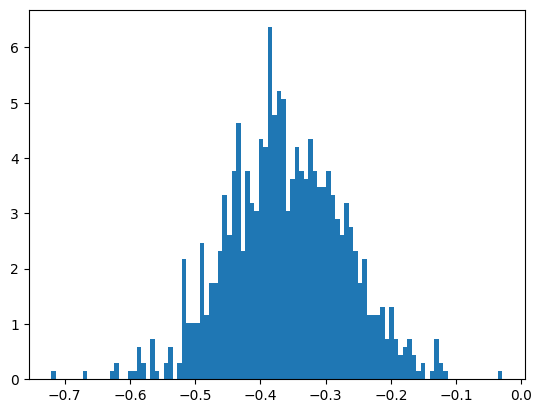

In [257]:
plt.hist(samples[:, -1,0], density=True, bins = 100)
#plt.plot(l,Z)